# Processamento de Imagens Oculares — Triple X

Pipeline de leitura do banco `dados_olhos` e identificação de regiões oculares.  
Suporta dois modos selecionados na célula de configuração:

| `MODE` | Método | Quando usar |
|--------|--------|-------------|
| `'classical'` | Hough + Sobel + Canny | Sem modelo treinado |
| `'ml'` | U-Net treinada no ARGaze | Após executar o bloco de treino |

**Regiões oculares (IDs compatíveis com ARGaze):**

| ID | Região |
|----|--------|
| 0 | Background |
| 1 | Íris |
| 2 | Pupila |
| 3 | Esclera |
| 4 | Pálpebra superior |
| 5 | Pálpebra inferior |
| 6 | Canto interno (medial) |
| 7 | Canto externo (lateral) |

## ⚙️ Configuração global

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURAÇÃO — edite aqui
# ══════════════════════════════════════════════════════════════════════════════

# Caminho para o CSV (relativo ao diretório do notebook)
CSV_PATH = r'dados_olhos (2).csv'

# Número máximo de amostras para exibição (None = todas)
MAX_SAMPLES = 10

# Modo de detecção: 'classical' ou 'ml'
MODE = 'ml'   # troque para 'ml' após treinar o modelo

# Caminho do modelo treinado (usado somente quando MODE='ml')
MODEL_PATH = 'models/ocular_unet_best.pth'

# Encoder do U-Net: 'mobilenet_v2' (leve) ou 'efficientnet-b0' (mais preciso)
ENCODER = 'mobilenet_v2'

# ══════════════════════════════════════════════════════════════════════════════
print(f'Modo de detecção: {MODE.upper()}')
print(f'CSV: {CSV_PATH} | MAX_SAMPLES: {MAX_SAMPLES}')

Modo de detecção: ML
CSV: dados_olhos (2).csv | MAX_SAMPLES: 10


## 1. Instalação de dependências

In [ ]:
import subprocess, sys

# Dependências base
base_pkgs = ['opencv-python-headless', 'numpy', 'pandas', 'matplotlib', 'Pillow', 'tqdm']

# Dependências ML (instaladas somente se necessário)
ml_pkgs = ['torch', 'torchvision', 'segmentation-models-pytorch', 'albumentations']

pkgs = base_pkgs + (ml_pkgs if MODE == 'ml' else [])
subprocess.run([sys.executable, '-m', 'pip', 'install', *pkgs, '--quiet'], check=True)
print('Dependências instaladas ✓')

Dependências instaladas ✓


## 2. Importações

In [ ]:
import cv2
import numpy as np
import pandas as pd
import base64
import os
import pathlib
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from collections import Counter
from IPython.display import display, Image as IPImage

# ─── Importações ML (carregadas apenas no modo ml) ────────────────────────────
if MODE == 'ml':
    import torch
    import torch.nn as nn
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import CosineAnnealingLR
    from torch.utils.data import Dataset, DataLoader, random_split
    import segmentation_models_pytorch as smp
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    from tqdm import tqdm
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'PyTorch {torch.__version__} | device: {DEVICE}')

# ─── IDs de regiões (compatíveis com as máscaras ARGaze) ─────────────────────
REGION_LABELS = {
    0: 'Background',
    1: 'Íris',
    2: 'Pupila',
    3: 'Esclera',
    4: 'Pálpebra superior',
    5: 'Pálpebra inferior',
    6: 'Canto interno (medial)',
    7: 'Canto externo (lateral)',
}

# ─── Paleta de cores para visualização ───────────────────────────────────────
REGION_PALETTE = {
    0: (0,   0,   0),
    1: (255, 165,  0),
    2: (0,   0, 255),
    3: (255, 255, 255),
    4: (0,  200,   0),
    5: (0,  100,   0),
    6: (255,  0, 255),
    7: (0,  255, 255),
}

# ─── Exibidor de imagens (substitui cv2_imshow do Colab) ─────────────────────
def imshow_nb(title: str, img: np.ndarray) -> None:
    if img is None:
        print(f'[ERRO] "{title}" é None.')
        return
    ch = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB if len(img.shape)==2 else cv2.COLOR_BGR2RGB)
    buf = BytesIO()
    Image.fromarray(ch).save(buf, format='PNG')
    buf.seek(0)
    print(f'─── {title} ───')
    display(IPImage(data=buf.read()))

print('Imports OK ✓')

PyTorch 2.10.0+cpu | device: cpu
Imports OK ✓


## 3. Leitura do banco de dados CSV

In [ ]:
df = pd.read_csv(CSV_PATH)
print(f'Total de registros : {len(df)}')
print(f'Colunas            : {list(df.columns)}')
print(f'Olhos              : {df["eye_side"].value_counts().to_dict()}')
print()
display(df[['data_id', 'sensor_name', 'eye_side', 'tempo']].head(8))

Total de registros : 376
Colunas            : ['data_id', 'sensor_name', 'eye_side', 'tempo', 'IMAG']
Olhos              : {'esquerdo': 376}



,data_id,sensor_name,eye_side,tempo
0,1,Triple,esquerdo,138
1,2,Triple,esquerdo,180
2,3,Triple,esquerdo,647
3,4,Triple,esquerdo,1102
4,5,Triple,esquerdo,1540
5,6,Triple,esquerdo,2005
6,7,Triple,esquerdo,2486
7,8,Triple,esquerdo,2950


## 4. Decodificação de imagens Base64

Imagem OK — shape: (240, 320, 3), dtype: uint8
  data_id=1 | olho=esquerdo | t=138ms
─── Sample #1 bruta ───


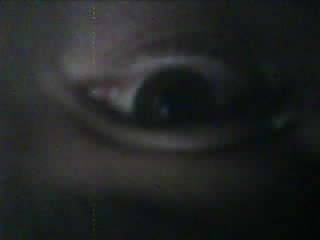

In [ ]:
def decode_image(b64: str) -> np.ndarray | None:
    """Decodifica string Base64 (JPEG) → array BGR do OpenCV."""
    try:
        if ',' in b64:
            b64 = b64.split(',', 1)[1]
        arr = np.frombuffer(base64.b64decode(b64), np.uint8)
        return cv2.imdecode(arr, cv2.IMREAD_COLOR)
    except Exception as e:
        print(f'[AVISO] Falha ao decodificar: {e}')
        return None

# Teste
sample = df.iloc[0]
img_test = decode_image(str(sample['IMAG']))
if img_test is not None:
    print(f'Imagem OK — shape: {img_test.shape}, dtype: {img_test.dtype}')
    print(f'  data_id={sample["data_id"]} | olho={sample["eye_side"]} | t={sample["tempo"]}ms')
    imshow_nb('Sample #1 bruta', img_test)

## 5. Pipeline CLÁSSICA de detecção de regiões

Usada quando `MODE='classical'`. Baseada em CLAHE + Sobel + Canny + Hough Circles.

In [ ]:
def preprocess_eye(img_bgr: np.ndarray, rotate_180: bool = True) -> np.ndarray:
    """Rotação + escala de cinza + CLAHE."""
    img = cv2.rotate(img_bgr, cv2.ROTATE_180) if rotate_180 else img_bgr.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)


def detect_edges(gray_eq: np.ndarray, thresh: int = 80) -> dict:
    """Binarização → Sobel → Canny."""
    _, binary = cv2.threshold(gray_eq, thresh, 255, cv2.THRESH_BINARY)
    sx = np.uint8(np.absolute(cv2.Sobel(binary, cv2.CV_64F, 1, 0, ksize=3)))
    sy = np.uint8(np.absolute(cv2.Sobel(binary, cv2.CV_64F, 0, 1, ksize=3)))
    img_or   = cv2.bitwise_or(sx, sy)
    img_not  = cv2.bitwise_not(sx, sy)
    img_fin  = cv2.bitwise_not(img_or, img_not)
    img_canny = cv2.Canny(img_fin, 140, 180)
    return {'binary': binary, 'sobelx': sx, 'sobely': sy,
            'combined': img_or, 'edges': img_canny}


def find_ocular_regions_classical(gray_eq: np.ndarray, edges: np.ndarray) -> dict:
    """Identifica regiões via Hough Circles + análise de contornos."""
    h, w = gray_eq.shape
    mask_map = np.zeros((h, w), dtype=np.uint8)
    regions_found = {}
    info_lines = []

    # Fechamento morfológico
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Hough Circles → pupila / íris
    blurred = cv2.GaussianBlur(gray_eq, (5, 5), 0)
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1,
                               minDist=max(h, w) // 8, param1=50, param2=30,
                               minRadius=int(min(h,w)*0.05),
                               maxRadius=int(min(h,w)*0.45))
    if circles is not None:
        cs = sorted(np.round(circles[0]).astype(int), key=lambda c: c[2])
        cx, cy, cr = cs[0]
        cv2.circle(mask_map, (cx, cy), cr, 2, -1)
        regions_found[2] = {'center': (cx, cy), 'radius': cr}
        info_lines.append(f'  Pupila: centro=({cx},{cy}), r={cr}px')
        if len(cs) > 1:
            ix, iy, ir = cs[1]
            if ir > cr:
                im = np.zeros_like(mask_map)
                cv2.circle(im, (ix, iy), ir, 255, -1)
                pm = np.zeros_like(mask_map)
                cv2.circle(pm, (cx, cy), cr, 255, -1)
                mask_map[cv2.bitwise_and(im, cv2.bitwise_not(pm)) == 255] = 1
                regions_found[1] = {'center': (ix, iy), 'radius': ir}
                info_lines.append(f'  Íris:  centro=({ix},{iy}), r={ir}px')
    else:
        info_lines.append('  [AVISO] Nenhum círculo detectado.')

    # Contornos → pálpebras / esclera
    cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cy_img = h // 2
    for cnt in cnts:
        if cv2.contourArea(cnt) < 50: continue
        M = cv2.moments(cnt)
        if M['m00'] == 0: continue
        cxc = int(M['m10'] / M['m00'])
        cyc = int(M['m01'] / M['m00'])
        _, _, cw, ch2 = cv2.boundingRect(cnt)
        label = (4 if cyc < cy_img else 5) if cw/(ch2+1e-6) > 2.5 else 3
        tmp = np.zeros((h, w), dtype=np.uint8)
        cv2.drawContours(tmp, [cnt], -1, 255, -1)
        mask_map[(tmp == 255) & (mask_map == 0)] = label
        regions_found.setdefault(label, []).append(
            {'area': cv2.contourArea(cnt), 'cx': cxc, 'cy': cyc})

    # Cantos
    cw2 = max(5, w // 10)
    mask_map[:, :cw2][mask_map[:, :cw2] == 0] = 6
    mask_map[:, -cw2:][mask_map[:, -cw2:] == 0] = 7
    regions_found.setdefault(6, {'x_range': (0, cw2)})
    regions_found.setdefault(7, {'x_range': (w-cw2, w)})

    found = sorted(regions_found)
    info_lines.insert(0, f'Regiões (clássico): {[REGION_LABELS[k] for k in found]}')
    return {'mask_map': mask_map, 'regions_found': regions_found,
            'info': chr(10).join(info_lines)}


def colorize_mask(mask_map: np.ndarray) -> np.ndarray:
    h, w = mask_map.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    for lid, color in REGION_PALETTE.items():
        out[mask_map == lid] = color
    return out


print('Pipeline clássica definida ✓')

Pipeline clássica definida ✓


## 6. Pipeline ML — U-Net com ARGaze

### 6.1 Dataset PyTorch para treino

In [ ]:
# ─── Executar apenas se MODE == 'ml' ─────────────────────────────────────────
if MODE == 'ml':
    from pathlib import Path

    class ARGazeDataset(Dataset):
        """Dataset de segmentação para o ARGaze.

        Estrutura esperada:
          <img_dir>/*.png   — imagens 32×32 RGB
          <mask_dir>/*.png  — máscaras uint8 (IDs 0-7, mesmo nome de arquivo)
        """
        NUM_CLASSES = 8

        _TRAIN_TF = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.4),
            A.GaussNoise(p=0.3),
            A.CLAHE(clip_limit=2.0, p=0.5),
            A.Normalize(mean=(0.5,)*3, std=(0.5,)*3),
            ToTensorV2(),
        ])

        _VAL_TF = A.Compose([
            A.Normalize(mean=(0.5,)*3, std=(0.5,)*3),
            ToTensorV2(),
        ])

        def __init__(self, img_dir, mask_dir, split='train'):
            self.paths    = sorted(Path(img_dir).glob('*.png'))
            self.mask_dir = Path(mask_dir)
            self.tf       = self._TRAIN_TF if split == 'train' else self._VAL_TF

        def __len__(self): return len(self.paths)

        def __getitem__(self, i):
            p    = self.paths[i]
            img  = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            mask = cv2.imread(str(self.mask_dir / p.name), cv2.IMREAD_GRAYSCALE)
            aug  = self.tf(image=img, mask=mask)
            return aug['image'], aug['mask'].long()

    print('ARGazeDataset definido ✓')
else:
    print('MODE=classical → bloco ML ignorado')

ARGazeDataset definido ✓


### 6.2 Construção do modelo U-Net

In [ ]:
if MODE == 'ml':
    def build_unet(encoder=ENCODER, num_classes=8):
        """U-Net com encoder pré-treinado no ImageNet."""
        return smp.Unet(
            encoder_name=encoder,
            encoder_weights='imagenet',
            in_channels=3,
            classes=num_classes,
            activation=None,    # logits → CrossEntropyLoss aplica softmax internamente
        )

    def mean_iou(logits: torch.Tensor, masks: torch.Tensor, nc: int = 8) -> float:
        pred = logits.argmax(dim=1)
        ious = []
        for c in range(nc):
            tp = ((pred == c) & (masks == c)).sum().item()
            fp = ((pred == c) & (masks != c)).sum().item()
            fn = ((pred != c) & (masks == c)).sum().item()
            if tp + fp + fn: ious.append(tp / (tp + fp + fn))
        return sum(ious) / len(ious) if ious else 0.0

    print(f'U-Net ({ENCODER}) definido ✓')
else:
    print('MODE=classical → bloco ignorado')

U-Net (mobilenet_v2) definido ✓


### 6.3 Treinamento no ARGaze

> **Pré-requisito:** dataset ARGaze organizado em:
> ```
> data/argaze/images/*.png
> data/argaze/masks/*.png
> ```
> Download: https://github.com/MobileGRID/ARGaze

In [ ]:
if MODE == 'ml':
    # ─── Hiperparâmetros ──────────────────────────────────────────────────────
    ARGAZE_IMAGES = 'data/argaze/images'
    ARGAZE_MASKS  = 'data/argaze/masks'
    BATCH_SIZE    = 64
    EPOCHS        = 50
    LR            = 3e-4
    VAL_SPLIT     = 0.2
    # ──────────────────────────────────────────────────────────────────────────

    if not pathlib.Path(ARGAZE_IMAGES).exists():
        print('[AVISO] Dataset ARGaze não encontrado em', ARGAZE_IMAGES)
        print('        Baixe de https://github.com/MobileGRID/ARGaze')
        print('        e extraia como:  data/argaze/images/  data/argaze/masks/')
    else:
        full_ds = ARGazeDataset(ARGAZE_IMAGES, ARGAZE_MASKS, split='train')
        n_val   = int(VAL_SPLIT * len(full_ds))
        train_ds, val_ds = random_split(full_ds, [len(full_ds)-n_val, n_val])
        val_ds.dataset.tf = ARGazeDataset._VAL_TF

        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
        val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        model     = build_unet().to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

        pathlib.Path('models').mkdir(exist_ok=True)
        best_miou = 0.0

        for epoch in range(1, EPOCHS + 1):
            # Treino
            model.train(); tl = 0.0
            for x, y in tqdm(train_dl, desc=f'Ep {epoch:3d}/{EPOCHS} [train]', leave=False):
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(x), y)
                loss.backward(); optimizer.step()
                tl += loss.item()

            # Validação
            model.eval(); vl = vm = 0.0
            with torch.no_grad():
                for x, y in val_dl:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    out  = model(x)
                    vl  += criterion(out, y).item()
                    vm  += mean_iou(out, y)
            vm /= len(val_dl); scheduler.step()

            print(f'Epoch {epoch:3d}/{EPOCHS} | '
                  f'train_loss={tl/len(train_dl):.4f} | '
                  f'val_loss={vl/len(val_dl):.4f} | '
                  f'mIoU={vm:.4f}')

            if vm > best_miou:
                best_miou = vm
                torch.save(model.state_dict(), MODEL_PATH)
                print(f'  ✓ Checkpoint salvo → {MODEL_PATH}  (mIoU={best_miou:.4f})')

        print(f'\nTreino concluído. Melhor mIoU: {best_miou:.4f}')
else:
    print('MODE=classical → treino ignorado')

[AVISO] Dataset ARGaze não encontrado em data/argaze/images
        Baixe de https://github.com/MobileGRID/ARGaze
        e extraia como:  data/argaze/images/  data/argaze/masks/


### 6.4 Fine-tuning no domínio Triple X (opcional)

Congela o encoder e re-treina apenas o decoder com anotações do sensor Triple X.

In [ ]:
if MODE == 'ml':
    # ─── Configuração de fine-tuning ─────────────────────────────────────────
    FINETUNE_IMAGES = 'data/triplex/images'   # ajuste para suas imagens anotadas
    FINETUNE_MASKS  = 'data/triplex/masks'
    FT_EPOCHS       = 20
    FT_LR           = 1e-4
    # ─────────────────────────────────────────────────────────────────────────

    if not pathlib.Path(FINETUNE_IMAGES).exists():
        print('[INFO] Diretório de fine-tuning não encontrado — etapa pulada.')
        print('       Crie masks para suas imagens e configure FINETUNE_IMAGES / FINETUNE_MASKS.')
    elif not pathlib.Path(MODEL_PATH).exists():
        print('[AVISO] Modelo base não encontrado. Execute a célula de treino primeiro.')
    else:
        ft_model = build_unet()
        ft_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        ft_model = ft_model.to(DEVICE)

        # Congela encoder
        for p in ft_model.encoder.parameters():
            p.requires_grad = False

        ft_ds = ARGazeDataset(FINETUNE_IMAGES, FINETUNE_MASKS, split='train')
        ft_dl = DataLoader(ft_ds, batch_size=32, shuffle=True, num_workers=2)
        ft_opt = AdamW(filter(lambda p: p.requires_grad, ft_model.parameters()), lr=FT_LR)
        ft_crit = nn.CrossEntropyLoss()

        for ep in range(1, FT_EPOCHS + 1):
            ft_model.train(); tl = 0.0
            for x, y in ft_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                ft_opt.zero_grad()
                loss = ft_crit(ft_model(x), y)
                loss.backward(); ft_opt.step()
                tl += loss.item()
            print(f'FT Ep {ep:3d}/{FT_EPOCHS} | loss={tl/len(ft_dl):.4f}')

        torch.save(ft_model.state_dict(), MODEL_PATH.replace('.pth', '_ft.pth'))
        print('Fine-tuning concluído ✓')
else:
    print('MODE=classical → fine-tuning ignorado')

[INFO] Diretório de fine-tuning não encontrado — etapa pulada.
       Crie masks para suas imagens e configure FINETUNE_IMAGES / FINETUNE_MASKS.


### 6.5 Função de inferência ML

Drop-in replacement de `find_ocular_regions_classical()` — retorna o mesmo tipo de dicionário.

In [ ]:
if MODE == 'ml':
    if not pathlib.Path(MODEL_PATH).exists():
        print(f'[AVISO] Modelo não encontrado em {MODEL_PATH}.')
        print('         Execute a célula de treino ou forneça um checkpoint existente.')
        _ml_model_ready = False
    else:
        _unet = build_unet()
        _unet.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        _unet.eval().to(DEVICE)

        _INFER_TF = A.Compose([
            A.Resize(32, 32),
            A.Normalize(mean=(0.5,)*3, std=(0.5,)*3),
            ToTensorV2(),
        ])
        _ml_model_ready = True
        print(f'Modelo U-Net carregado de {MODEL_PATH} ✓')


# @torch.no_grad()
def find_ocular_regions_ml(img_bgr: np.ndarray) -> dict:
    """
    Segmentação de regiões oculares usando U-Net treinada no ARGaze.
    Retorna o mesmo formato de dicionário que find_ocular_regions_classical().
    """
    if not _ml_model_ready:
        raise RuntimeError('Modelo ML não carregado. Verifique MODEL_PATH.')

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor  = _INFER_TF(image=img_rgb)['image'].unsqueeze(0).to(DEVICE)
    pred    = _unet(tensor).argmax(dim=1).squeeze(0).cpu().numpy()  # (32, 32)

    h, w    = img_bgr.shape[:2]
    mask_map = cv2.resize(pred.astype(np.uint8), (w, h),
                          interpolation=cv2.INTER_NEAREST)

    regions_found = {}
    for lid in np.unique(mask_map):
        if lid == 0: continue
        px = int((mask_map == lid).sum())
        regions_found[int(lid)] = {
            'pixel_count':  px,
            'coverage_pct': round(100 * px / (h * w), 1),
        }

    found_names = [REGION_LABELS[k] for k in sorted(regions_found)]
    lines = [f'Regiões (ML U-Net): {found_names}']
    for lid, s in sorted(regions_found.items()):
        lines.append(f'  {REGION_LABELS[lid]:25s}: {s["pixel_count"]:5d}px ({s["coverage_pct"]}%)')

    return {'mask_map': mask_map, 'regions_found': regions_found, 'info': chr(10).join(lines)}


if MODE != 'ml':
    print('MODE=classical → inferência ML não carregada')

[AVISO] Modelo não encontrado em models/ocular_unet_best.pth.
         Execute a célula de treino ou forneça um checkpoint existente.


## 7. Dispatcher — seleciona método automaticamente por `MODE`

In [ ]:
def detect_regions(img_bgr: np.ndarray) -> dict:
    """
    Ponto de entrada único para detecção de regiões.
    Redireciona para a pipeline clássica ou ML conforme MODE.
    """
    if MODE == 'ml':
        return find_ocular_regions_ml(img_bgr)
    else:
        gray_eq   = preprocess_eye(img_bgr)
        edge_dict = detect_edges(gray_eq)
        return find_ocular_regions_classical(gray_eq, edge_dict['edges'])

print(f'Dispatcher configurado → modo: {MODE.upper()} ✓')

Dispatcher configurado → modo: ML ✓


## 8. Processamento do banco de dados

In [ ]:
subset  = df.head(MAX_SAMPLES) if MAX_SAMPLES else df
results = []

for idx, row in subset.iterrows():
    data_id  = row['data_id']
    eye_side = row['eye_side']
    tempo    = row['tempo']

    # Decodificar
    img_bgr = decode_image(str(row['IMAG']))
    if img_bgr is None:
        print(f'[AVISO] data_id={data_id}: imagem inválida, pulando.')
        continue

    # Detectar regiões (classical ou ml)
    ocular = detect_regions(img_bgr)

    # Exibir
    print(f'\n══ data_id={data_id} | olho={eye_side} | t={tempo}ms ══')
    print(ocular['info'])

    # Mosaico: original | CLAHE/cinza | mapa de regiões colorido
    regions_vis = colorize_mask(ocular['mask_map'])
    if MODE == 'classical':
        gray_eq   = preprocess_eye(img_bgr)
        gray_3ch  = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2BGR)
        edge_dict = detect_edges(gray_eq)
        edges_3ch = cv2.cvtColor(edge_dict['edges'], cv2.COLOR_GRAY2BGR)
        mosaic    = np.hstack([img_bgr, gray_3ch, edges_3ch, regions_vis])
        label_str = 'Original | CLAHE | Bordas | Regiões'
    else:
        mosaic    = np.hstack([img_bgr, regions_vis])
        label_str = 'Original | Regiões (U-Net)'

    imshow_nb(f'#{data_id} — {label_str}', mosaic)

    # Tabular
    found_labels = [REGION_LABELS[k] for k in sorted(ocular['regions_found'])]
    results.append({
        'data_id':       data_id,
        'eye_side':      eye_side,
        'tempo_ms':      tempo,
        'modo':          MODE,
        'img_shape':     str(img_bgr.shape),
        'regioes_ids':   sorted(ocular['regions_found']),
        'regioes_nomes': found_labels,
        'n_regioes':     len(found_labels),
    })

print('\n\n=== Processamento concluído ===')

RuntimeError: Modelo ML não carregado. Verifique MODEL_PATH.

## 9. Resumo dos resultados

In [ ]:
df_res = pd.DataFrame(results)
print('Tabela de regiões identificadas:')
display(df_res[['data_id', 'eye_side', 'tempo_ms', 'modo', 'n_regioes', 'regioes_nomes']])

# Frequência por região
all_r = [r for sub in df_res['regioes_nomes'] for r in sub]
freq  = Counter(all_r)
print(f'\nFrequência de regiões (N={len(df_res)} imagens):')
for reg, cnt in sorted(freq.items(), key=lambda x: -x[1]):
    pct = 100 * cnt / len(df_res)
    bar = '█' * int(pct / 5)
    print(f'  {reg:28s}: {cnt:3d}  {bar} ({pct:.0f}%)')

## 10. Exportação

In [ ]:
OUTPUT = f'resultados_regioes_{MODE}.csv'
df_out = df_res.copy()
df_out['regioes_ids']   = df_out['regioes_ids'].astype(str)
df_out['regioes_nomes'] = df_out['regioes_nomes'].astype(str)
df_out.to_csv(OUTPUT, index=False, encoding='utf-8')
print(f'Resultados exportados → {OUTPUT}')